In [16]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Titanic Survival Prediction

In [7]:
df = pd.read_csv('../Dataset/titanic.csv')

In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [12]:
df = df.drop('Cabin',axis = 1)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


In [14]:
df = df.dropna()

In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Name         712 non-null    str    
 4   Sex          712 non-null    str    
 5   Age          712 non-null    float64
 6   SibSp        712 non-null    int64  
 7   Parch        712 non-null    int64  
 8   Ticket       712 non-null    str    
 9   Fare         712 non-null    float64
 10  Embarked     712 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 66.8 KB


<Axes: >

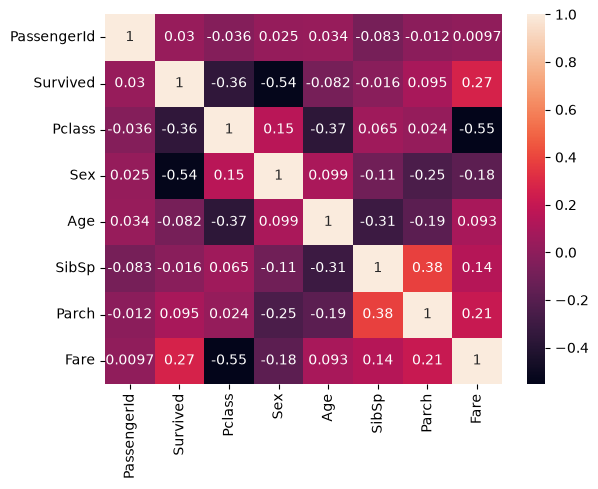

In [27]:
corr = df.corr(numeric_only = True)
sns.heatmap(
    data = corr,
    annot = True
)

In [20]:
df['Sex'] = df['Sex'].str.lower()

In [21]:
df['Sex'].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [24]:
df.loc[df['Sex']=='male','Sex'] = '1'
df.loc[df['Sex']=='female','Sex'] = '0'

In [25]:
df['Sex'] = df['Sex'].astype('int64')

In [26]:
df.info()

<class 'pandas.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Name         712 non-null    str    
 4   Sex          712 non-null    int64  
 5   Age          712 non-null    float64
 6   SibSp        712 non-null    int64  
 7   Parch        712 non-null    int64  
 8   Ticket       712 non-null    str    
 9   Fare         712 non-null    float64
 10  Embarked     712 non-null    str    
dtypes: float64(2), int64(6), str(3)
memory usage: 66.8 KB


In [50]:
df['Pclass'].unique()

array([3, 1, 2])

In [38]:
temp = df.groupby('Pclass').corr(numeric_only = True)['Survived']

In [39]:
test = temp.reset_index()

In [43]:
test.columns

Index(['Pclass', 'level_1', 'Survived'], dtype='str')

In [44]:
test = test[test['level_1'] != 'Survived']

In [45]:
test

,Pclass,level_1,Survived
0,1,PassengerId,0.205613
2,1,Sex,-0.593235
3,1,Age,-0.276971
4,1,SibSp,0.112136
5,1,Parch,0.037952
6,1,Fare,0.186391
7,2,PassengerId,-0.017446
9,2,Sex,-0.759971
10,2,Age,-0.273507
11,2,SibSp,0.142231


In [46]:
test = test.sort_values('Survived',ascending = False)

In [49]:
test

,Pclass,level_1,Survived
12,2,Parch,0.368548
0,1,PassengerId,0.205613
6,1,Fare,0.186391
11,2,SibSp,0.142231
4,1,SibSp,0.112136
13,2,Fare,0.056749
19,3,Parch,0.042265
5,1,Parch,0.037952
20,3,Fare,0.008783
7,2,PassengerId,-0.017446


In [53]:
x = df[['Sex','Pclass','Parch']]
y = df['Survived']

x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size = .2,random_state = 43
)

In [54]:
model = LogisticRegression()
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [56]:
y_pred = model.predict(x_test)

In [58]:
cm = confusion_matrix(y_test,y_pred)


array([[77, 15],
       [17, 34]])

In [74]:
tp,fp,tn,fn = 0,0,0,0
temp = zip(y_test,y_pred)
for actual,pred in temp:
    if actual == 1:
        if pred == 1:
            tp += 1
        if pred == 0:
            fn += 1
    elif actual == 0:
        if pred == 1:
            fp += 1
        if pred == 0:
            tn += 1
cm = np.array([[tn,fp],[fn,tp]])

In [75]:
cm

array([[77, 15],
       [17, 34]])

In [76]:
accuracy = (tp + tn) / (tp+tn+fn+fp)
accuracy

0.7762237762237763

In [79]:
accuracy = accuracy_score(y_test,y_pred)

In [80]:
accuracy

0.7762237762237763

In [82]:
precision = tp/(fp+tp)
precision

0.6938775510204082

In [84]:
precision  = precision_score(y_test,y_pred)
precision

0.6938775510204082

In [85]:
recall = tp / (tp+fn)
recall

0.6666666666666666

In [86]:
recall = recall_score(y_test,y_pred)
recall

0.6666666666666666

In [101]:
f1 = 2*(precision*recall)/(precision + recall)
f1

0.6799999999999999

In [102]:
fl = f1_score(y_test,y_pred)
f1

0.6799999999999999

In [ ]:
f1 = 0.679
recall = 0.66
precision = 0.693 ~~ 0.7
accuracy = 0.77

<Axes: xlabel='Survived', ylabel='count'>

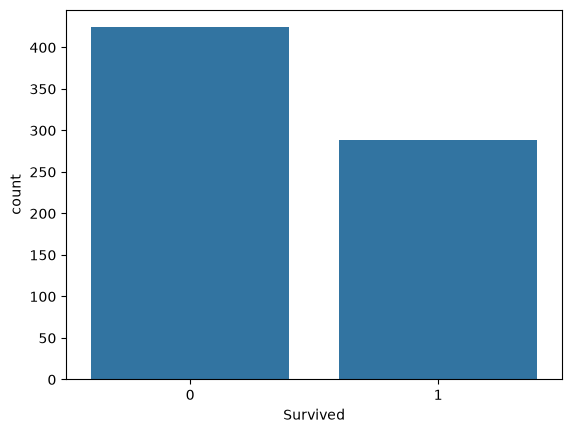

In [93]:
sns.countplot(
    data = df,
    x = 'Survived'
)

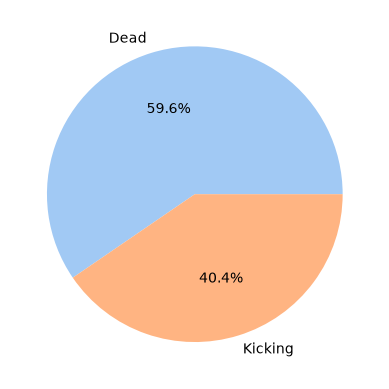

In [100]:
counts = df['Survived'].value_counts()
colors = sns.color_palette('pastel')[0:len(counts)]
plt.pie(
    counts,
    labels = ['Dead','Kicking'],
    autopct = "%1.1f%%",
    colors = colors
)
plt.show()